# Dataset 7 — Statlog (Australian Credit Approval)

## Descripción general
Este dataset, proveniente del proyecto Statlog, es una versión optimizada del dataset de aprobación de créditos australianos. A diferencia de la versión cruda, aquí los atributos categóricos ya han sido codificados numéricamente por el equipo de Statlog para facilitar el procesamiento algorítmico, manteniendo la confidencialidad de los solicitantes mediante etiquetas anónimas.

## Objetivo
**Problema de Clasificación Binaria** — Predecir la viabilidad de una solicitud de tarjeta de crédito (Aprobado: `1`, Rechazado: `0`) analizando un perfil compuesto por 14 atributos que mezclan datos continuos y categóricos.

## Estructura original
- **Archivo:** `australian.dat` (690 instancias).
- **Columnas:** 14 atributos predictores + 1 variable objetivo (`A15`).
- **Naturaleza:** 6 atributos numéricos y 8 categóricos (codificados originalmente como números).

## Tratamiento aplicado

### 1. Carga y Estructuración
Debido a que el archivo original no posee encabezados y utiliza espacios múltiples como delimitadores, se cargó utilizando una expresión regular (`sep='\s+'`) y se asignaron etiquetas anónimas de la **A1** a la **A15** para mantener la consistencia con la documentación técnica.

### 2. Ingeniería de Variables Categóricas
Un punto crítico de este dataset es que las variables categóricas (como **A4, A5, A6**, etc.) ya vienen representadas por números en el archivo `.dat`. 
- **Acción:** Se forzó la conversión de estas 8 columnas a tipo *string* antes de aplicar **One-Hot Encoding**. 
- **Justificación:** Evita que el modelo interprete órdenes de magnitud falsos (ej. que la categoría 4 es "mayor" que la 1), separándolas en columnas binarias independientes.

### 3. Balanceo de Clases (Undersampling)
Se analizó la distribución de la variable `A15`. Para garantizar un entrenamiento equitativo, se aplicó un proceso de **submuestreo aleatorio (Undersampling)** para equilibrar el dataset al **50/50**.

### 4. Preparación Matemática (Z-Score)
- **División de datos:** Partición de **80% entrenamiento** y **20% pruebas**.
- **Estandarización:** Se aplicó normalización Z-score para igualar las magnitudes de las variables continuas y las generadas por el encoding.
- **Columna de sesgo:** Se insertó un vector de unos en la posición inicial para habilitar el aprendizaje del parámetro de intercepto ($\theta_0$).

## Resultado final
| Métrica | Antes | Después |
|--|-------|---------|
| **Filas** | 690 | 614 (Balanceadas 50/50) |
| **Columnas** | 15 | 43 (incluyendo bias) |
| **Valores faltantes** | 0 | 0 |
| **Balance de clases** | ~55% / 45% | 50% / 50% |

## ¿Está balanceado?
**Sí.** Tras el proceso de Undersampling, el dataset cuenta con una distribución equitativa de clases. Esto elimina el riesgo de que el modelo desarrolle un "sesgo de mayoría" y permite que la métrica de *Accuracy* sea una representación fiel del desempeño real del algoritmo en la toma de decisiones crediticias.

Shape original: (690, 15)

Variable objetivo - A15 (Distribución original):
A15
0    383
1    307
Name: count, dtype: int64

No se requiere eliminación de columnas por irrelevancia.
Ninguna columna superó el 50% de nulos.
NaN restantes totales: 0
Shape después de one-hot encoding: (690, 43)

Balanceando las clases (Undersampling)...
Distribución después del balanceo:
A15
1    307
0    307
Name: count, dtype: int64

 DESCRIPCIÓN DEL DATASET PREPARADO 
Nombre: Australian Credit Approval (Statlog)
Problema: Clasificación Binaria
Filas finales: 614
Columnas finales: 43

Dataset guardado como 'Australian_preparado.csv'

 INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN 
Tamaño X_train_norm: (491, 43)
Tamaño X_test_norm:  (123, 43)


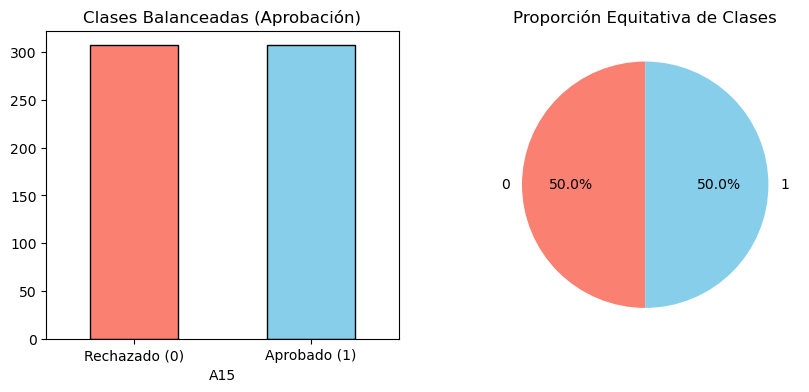

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PREPARACIÓN DATASET 7: Australian Credit (Clasificación)

# 1. CARGAR
ruta_aust = r"C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset7\statlog+australian+credit+approval\australian.dat"

# Definimos nombres de columnas A1-A15 (según documentación Statlog)
columnas = [f'A{i}' for i in range(1, 16)]

# El archivo .dat usa espacios como separador
df = pd.read_csv(ruta_aust, sep='\s+', names=columnas)

print("Shape original:", df.shape)
print("\nVariable objetivo - A15 (Distribución original):")
print(df['A15'].value_counts())

# 2. ELIMINAR COLUMNAS INÚTILES
# Este dataset ya fue pre-procesado por Statlog; todas las variables son relevantes.
print("\nNo se requiere eliminación de columnas por irrelevancia.")

# 3. ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
if cols_muchos_nulos:
    df = df.drop(columns=cols_muchos_nulos)
else:
    print("Ninguna columna superó el 50% de nulos.")

# 4. IMPUTAR NaN RESTANTES
# Imputamos con mediana para mantener la integridad estadística
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
for col in cols_numericas:
    if col == 'A15': continue
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("NaN restantes totales:", df.isnull().sum().sum())

# 5. ONE-HOT ENCODING (Variables Categóricas Numéricas)
# Según australian.doc, las columnas 1, 4, 5, 6, 8, 9, 11 y 12 son categóricas.
# Debemos pasarlas a string para que el encoding no las trate como magnitudes.
cols_categoricas = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
for col in cols_categoricas:
    df[col] = df[col].astype(str)

df = pd.get_dummies(df, columns=cols_categoricas)
print("Shape después de one-hot encoding:", df.shape)

# 6. BALANCEAR CLASES (Undersampling)
print("\nBalanceando las clases (Undersampling)...")
clase_mayoritaria = df[df['A15'] == 0]
clase_minoritaria = df[df['A15'] == 1]

# Igualamos ambas clases a la cantidad de la minoritaria
clase_mayoritaria_reducida = clase_mayoritaria.sample(n=len(clase_minoritaria), random_state=42)
df = pd.concat([clase_mayoritaria_reducida, clase_minoritaria])

# Mezclamos los datos
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Distribución después del balanceo:")
print(df['A15'].value_counts())

# 7. MOVER TARGET AL FINAL
cols = [c for c in df.columns if c != 'A15'] + ['A15']
df = df[cols]

# 8. RESUMEN FINAL
print("\n DESCRIPCIÓN DEL DATASET PREPARADO ")
print(f"Nombre: Australian Credit Approval (Statlog)")
print(f"Problema: Clasificación Binaria")
print(f"Filas finales: {df.shape[0]}")
print(f"Columnas finales: {df.shape[1]}")

# 9. GUARDAR
df.to_csv('Australian_preparado.csv', index=False)
print("\nDataset guardado como 'Australian_preparado.csv'")


# 10. DIVISIÓN 80/20 Y NORMALIZACIÓN MATEMÁTICA

print("\n INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN ")

# .astype(float) para asegurar compatibilidad con matrices Numpy
X = df.drop('A15', axis=1).astype(float).values
y = df['A15'].values

m = len(y)
limite = int(m * 0.8)

# División entrenamiento y prueba
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Función manual de normalización Z-score
def normalizar(X_data):
    mu = np.mean(X_data, axis=0)
    sigma = np.std(X_data, axis=0)
    sigma[sigma == 0] = 1 
    return (X_data - mu) / sigma, mu, sigma

X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm = (X_test - mu) / sigma

# Agregar columna de unos para el término de sesgo (theta_0)
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Tamaño X_train_norm: {X_train_norm.shape}")
print(f"Tamaño X_test_norm:  {X_test_norm.shape}")

# 11. GRÁFICAS
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['A15'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'], edgecolor='black')
plt.title("Clases Balanceadas (Aprobación)")
plt.xticks([0, 1], ['Rechazado (0)', 'Aprobado (1)'], rotation=0)

plt.subplot(1, 2, 2)
plt.pie(df['A15'].value_counts(), labels=['0', '1'], autopct='%1.1f%%', colors=['salmon', 'skyblue'], startangle=90)
plt.title("Proporción Equitativa de Clases")
plt.show()